<h1 style="text-align:center; font-size:42px; margin-top:40px;">

Analyse exploratoire – Technologies utilisées : Bases de données, plateformes, frameworks, embedded & outils d’IA  
(Survey 2024)

</h1>


## 1. Contexte et objectif

Ce module analyse les technologies utilisées et souhaitées par les développeurs dans plusieurs catégories clés du Stack Overflow Developer Survey 2024 :

- Bases de données (Have / Want)
- Plateformes (Have / Want)
- Frameworks Web (Have / Want)
- Technologies Embedded (Have / Want)
- Systèmes d'exploitation utilisés professionnellement
- Outils collaboratifs utilisés
- Outils d’IA utilisés actuellement

L’objectif est d’identifier les technologies réellement adoptées, celles qui suscitent un fort intérêt, et les tendances générales du marché selon les développeurs.

Les résultats serviront de base aux analyses globales du paysage technologique dans le storytelling final.

---


## 2. Librairies & chargement des données

In [28]:
## 2. Librairies & chargement des données
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

df = pd.read_csv("../Data/Survey/processed/survey-data_V3_final.csv")
nb_repondants = df["ResponseId"].nunique()
nb_repondants

61201

## 3. Aperçu des colonnes analysées

In [29]:
cols_used = [
    "ResponseId",
    "DatabaseHaveWorkedWith", "DatabaseWantToWorkWith",
    "PlatformHaveWorkedWith", "PlatformWantToWorkWith",
    "WebframeHaveWorkedWith", "WebframeWantToWorkWith",
    "EmbeddedHaveWorkedWith", "EmbeddedWantToWorkWith",
    "OpSysProfessional use",
    "NEWCollabToolsHaveWorkedWith",
    "AIToolCurrently Using"
]

df[cols_used].head()

,ResponseId,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,PlatformHaveWorkedWith,PlatformWantToWorkWith,WebframeHaveWorkedWith,WebframeWantToWorkWith,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,OpSysProfessional use,NEWCollabToolsHaveWorkedWith,AIToolCurrently Using
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,NaN,NaN,MacOS,PyCharm;Visual Studio Code;WebStorm,NaN
2,3,Firebase Realtime Database,Firebase Realtime Database,Google Cloud,Google Cloud,ASP.NET CORE,ASP.NET CORE,Rasberry Pi,Rasberry Pi,Windows,Visual Studio,NaN
3,4,MongoDB;MySQL;PostgreSQL;SQLite,MongoDB;MySQL;PostgreSQL,Amazon Web Services (AWS);Fly.io;Heroku,Amazon Web Services (AWS);Vercel,jQuery;Next.js;Node.js;React;WordPress,jQuery;Next.js;Node.js;React,Rasberry Pi,NaN,NaN,NaN,Learning about a codebase;Project planning;Wri...
4,5,PostgreSQL;SQLite,PostgreSQL;SQLite,NaN,NaN,NaN,NaN,CMake;Cargo;Rasberry Pi,CMake;Rasberry Pi,NaN,Vim,NaN


## 4. Bases de données (Database)

### 4.1. Bases de données utilisées (DatabaseHaveWorkedWith)

In [30]:
# Extraction simple : uniquement les répondants et les BDD utilisées
db_have = df[["ResponseId", "DatabaseHaveWorkedWith"]].dropna(
    subset=["DatabaseHaveWorkedWith"]
).copy()

db_have["DatabaseHaveWorkedWith"] = db_have["DatabaseHaveWorkedWith"].str.split(";")
db_have = db_have.explode("DatabaseHaveWorkedWith")
db_have["DatabaseHaveWorkedWith"] = db_have["DatabaseHaveWorkedWith"].str.strip()

db_have_pct = (
    db_have["DatabaseHaveWorkedWith"]
    .value_counts()
    .head() * 100 / nb_repondants
).round(2)

db_have_pct


DatabaseHaveWorkedWith
PostgreSQL              40.76
MySQL                   33.27
SQLite                  27.51
Microsoft SQL Server    21.28
MongoDB                 20.46
Name: count, dtype: float64

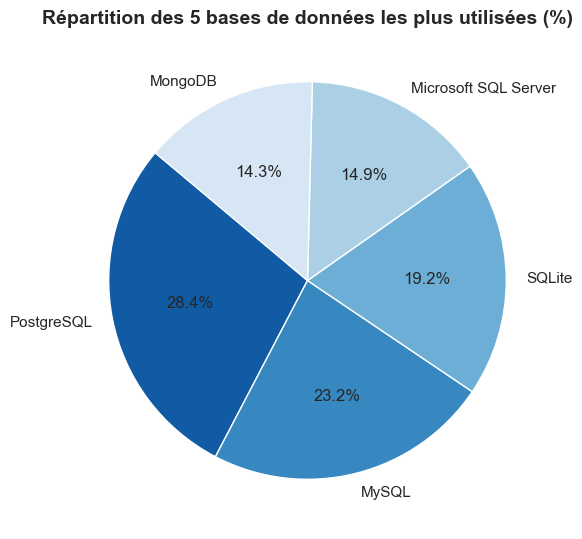

In [31]:
plt.figure(figsize=(6, 6))

plt.pie(
    db_have_pct.values,
    labels=db_have_pct.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("Blues_r", len(db_have_pct))
)

plt.title("Répartition des 5 bases de données les plus utilisées (%)",
          fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../Reports/Figures/Technologies/Databases/09_db_used_top5.png", dpi=300, bbox_inches='tight')
plt.show()


### 4.2. Bases de données souhaitées (DatabaseWantToWorkWith)

In [32]:
db_want = df[["ResponseId", "DatabaseWantToWorkWith"]].dropna(
    subset=["DatabaseWantToWorkWith"]
).copy()

db_want["DatabaseWantToWorkWith"] = db_want["DatabaseWantToWorkWith"].str.split(";")
db_want = db_want.explode("DatabaseWantToWorkWith")
db_want["DatabaseWantToWorkWith"] = db_want["DatabaseWantToWorkWith"].str.strip()

# Top 10 des BDD souhaitées (%)
db_want_pct = (
    db_want["DatabaseWantToWorkWith"]
    .value_counts()
    .head(5) * 100 / nb_repondants
).round(2)

db_want_pct


DatabaseWantToWorkWith
PostgreSQL    38.30
SQLite        21.44
MySQL         19.36
Redis         17.32
MongoDB       17.25
Name: count, dtype: float64

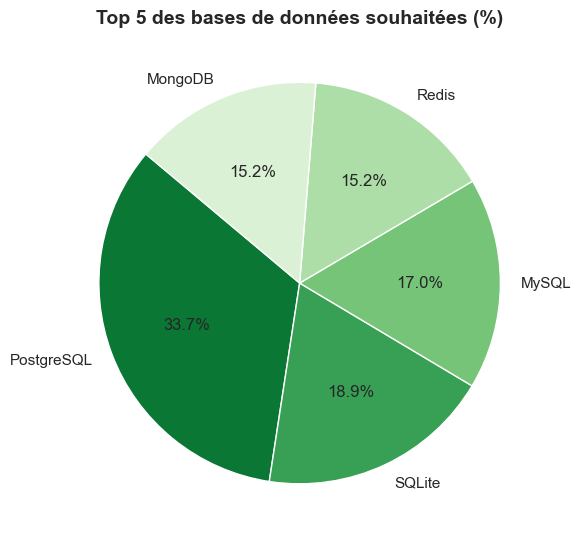

In [33]:
plt.figure(figsize=(6, 6))

plt.pie(
    db_want_pct.values,
    labels=db_want_pct.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("Greens_r", len(db_want_pct))  # palette verte
)

plt.title("Top 5 des bases de données souhaitées (%)",
          fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../Reports/Figures/Technologies/Databases/09_db_wanted_top5.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation

- Les bases de données les plus utilisées restent dominées par des solutions SQL gratuites et matures comme PostgreSQL, MySQL et SQLite.

- Dans les préférences futures, PostgreSQL s’impose nettement, tandis que MongoDB et Redis gagnent en attractivité grâce à leur simplicité, leur performance et leur modèle open-source.

- Globalement, l’usage actuel reflète l’héritage des systèmes installés, tandis que les souhaits montrent une transition vers des solutions plus modernes, flexibles et sans coûts de licence.


## 5. Plateformes (Platform)

### 5.1. Plateformes utilisées (PlatformHaveWorkedWith)

In [34]:
# Extraction : répondants + plateformes utilisées
plat_have = df[["ResponseId", "PlatformHaveWorkedWith"]].dropna(
    subset=["PlatformHaveWorkedWith"]
).copy()

plat_have["PlatformHaveWorkedWith"] = plat_have["PlatformHaveWorkedWith"].str.split(";")
plat_have = plat_have.explode("PlatformHaveWorkedWith")
plat_have["PlatformHaveWorkedWith"] = plat_have["PlatformHaveWorkedWith"].str.strip()

# Top 5 des plateformes utilisées (en % des répondants)
plat_have_pct = (
    plat_have["PlatformHaveWorkedWith"]
    .value_counts()
    .head(5) * 100 / nb_repondants
).round(2)

plat_have_pct



PlatformHaveWorkedWith
Amazon Web Services (AWS)    35.53
Microsoft Azure              20.63
Google Cloud                 18.50
Cloudflare                   11.07
Firebase                     10.14
Name: count, dtype: float64

C:\Users\lenovo\AppData\Local\Temp\ipykernel_2580\917264236.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


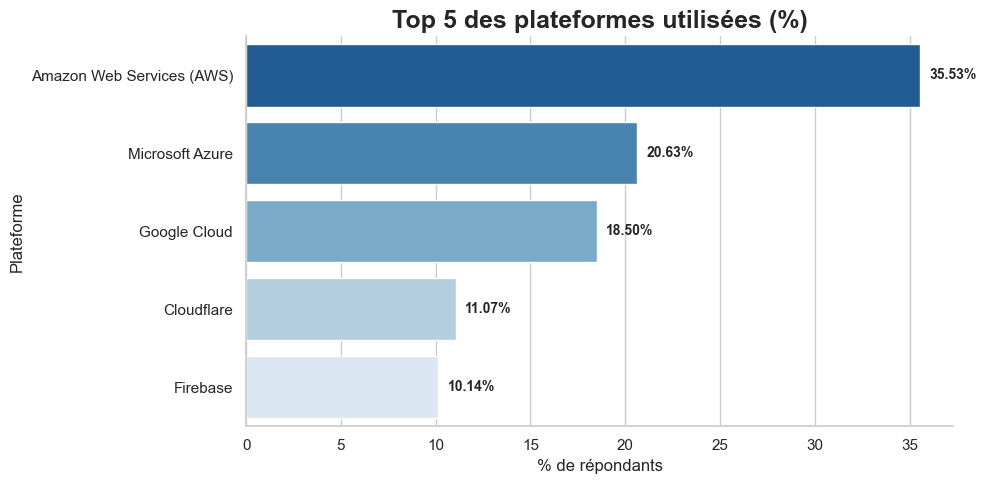

In [35]:
# Trier les valeurs pour appliquer un dégradé logique
plat_have_pct_sorted = plat_have_pct.sort_values(ascending=False)

# Générer une palette du plus foncé (max) au plus clair (min)
colors = sns.color_palette("Blues_r", len(plat_have_pct_sorted))  # Blues_r = foncé → clair

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=plat_have_pct_sorted.values,
    y=plat_have_pct_sorted.index,
    palette=colors,

)

# Ajouter les % sur les barres
for i, v in enumerate(plat_have_pct_sorted.values):
    ax.text(
        v + 0.5, 
        i,
        f"{v:.2f}%",
        va="center",
        fontweight="bold",
        fontsize=10
    )

plt.title("Top 5 des plateformes utilisées (%)", fontsize=18, fontweight="bold")
plt.xlabel("% de répondants")
plt.ylabel("Plateforme")

sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Technologies/Platforms/09_platform_used_top5.png", dpi=300, bbox_inches='tight')
plt.show()


### 5.2. Plateformes souhaitées (PlatformWantToWorkWith)

In [36]:
plat_want = df[["ResponseId", "PlatformWantToWorkWith"]].dropna(
    subset=["PlatformWantToWorkWith"]
).copy()

plat_want["PlatformWantToWorkWith"] = plat_want["PlatformWantToWorkWith"].str.split(";")
plat_want = plat_want.explode("PlatformWantToWorkWith")
plat_want["PlatformWantToWorkWith"] = plat_want["PlatformWantToWorkWith"].str.strip()

# Top 5 des plateformes souhaitées (en % des répondants)
plat_want_pct = (
    plat_want["PlatformWantToWorkWith"]
    .value_counts()
    .head(5) * 100 / nb_repondants
).round(2)

plat_want_pct



PlatformWantToWorkWith
Amazon Web Services (AWS)    28.79
Microsoft Azure              16.51
Google Cloud                 15.53
Cloudflare                   10.91
Firebase                      7.76
Name: count, dtype: float64

C:\Users\lenovo\AppData\Local\Temp\ipykernel_2580\1755674420.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


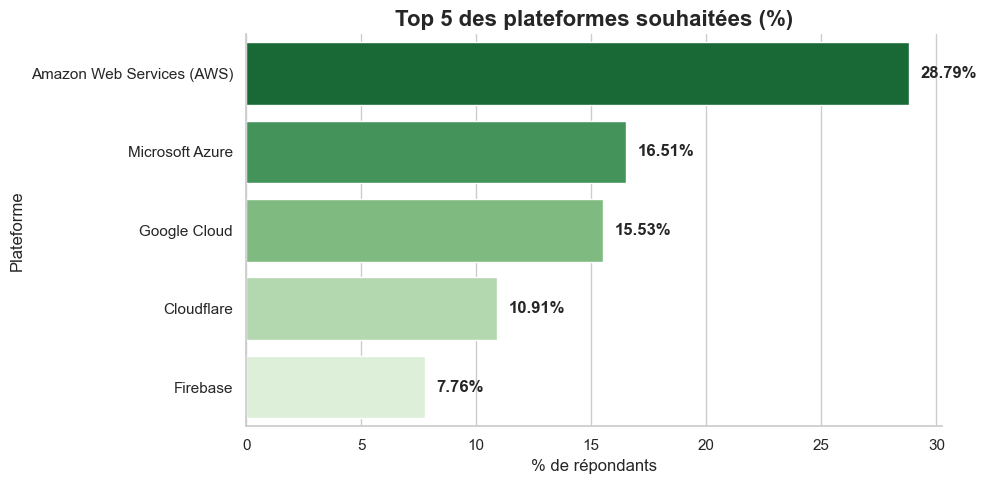

In [37]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=plat_want_pct.values,
    y=plat_want_pct.index,
    palette="Greens_r"
)

for i, v in enumerate(plat_want_pct.values):
    ax.text(v + 0.5, i, f"{v:.2f}%", va="center", fontweight="bold")

plt.title("Top 5 des plateformes souhaitées (%)", fontsize=16, fontweight="bold")
plt.xlabel("% de répondants")
plt.ylabel("Plateforme")

sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Technologies/Platforms/09_platform_wanted_top5.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation
L’usage réel comme les préférences futures confirment une forte domination d’AWS, qui reste la plateforme la plus utilisée et la plus désirée par les développeurs. Azure et Google Cloud occupent des positions solides mais nettement derrière, ce qui reflète la structure actuelle du marché cloud : AWS en tête, suivi d’un duo Microsoft–Google. Cloudflare et Firebase complètent le classement, davantage présents dans des usages spécialisés liés au web, aux CDN et aux applications mobiles.
Au global, les développeurs montrent une préférence stable pour les trois grands fournisseurs cloud, avec un avantage clair pour AWS, considéré comme la référence du secteur.

## 6. Frameworks Web (Webframe)


### 6.1. Frameworks utilisés (WebframeHaveWorkedWith)

In [38]:
fw_have = df[["ResponseId", "WebframeHaveWorkedWith"]].dropna(
    subset=["WebframeHaveWorkedWith"]
).copy()

fw_have["WebframeHaveWorkedWith"] = fw_have["WebframeHaveWorkedWith"].str.split(";")
fw_have = fw_have.explode("WebframeHaveWorkedWith")
fw_have["WebframeHaveWorkedWith"] = fw_have["WebframeHaveWorkedWith"].str.strip()

fw_have_pct = (
    fw_have["WebframeHaveWorkedWith"]
    .value_counts()
    .head(5) * 100 / nb_repondants
).round(2)

fw_have_pct



WebframeHaveWorkedWith
Node.js    31.23
React      30.39
jQuery     16.55
Next.js    13.68
Express    13.60
Name: count, dtype: float64

C:\Users\lenovo\AppData\Local\Temp\ipykernel_2580\4199799337.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


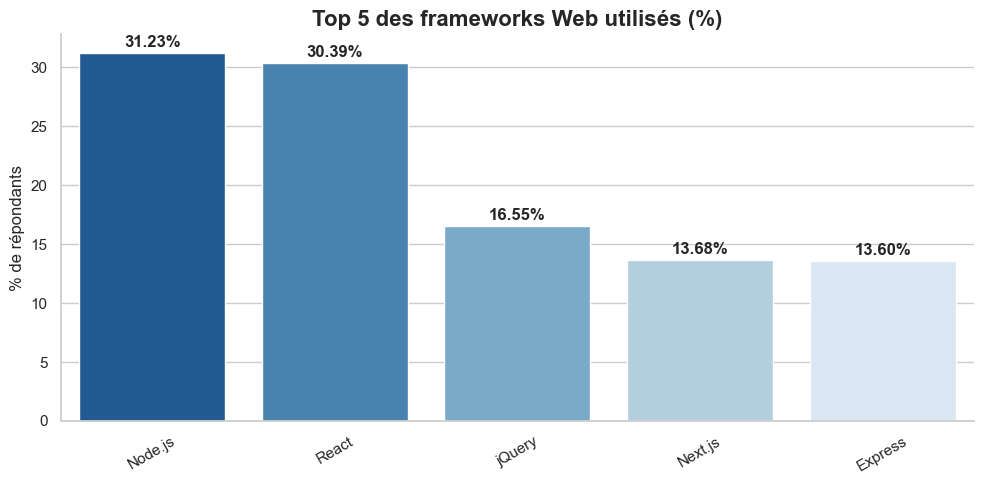

In [39]:
fw_sorted = fw_have_pct.sort_values(ascending=False)
colors = sns.color_palette("Blues_r", len(fw_sorted))

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=fw_sorted.index,
    y=fw_sorted.values,
    palette=colors
)

for i, v in enumerate(fw_sorted.values):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center", fontweight="bold")

plt.title("Top 5 des frameworks Web utilisés (%)", fontsize=16, fontweight="bold")
plt.xlabel("")
plt.ylabel("% de répondants")
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Technologies/Frameworks/09_webframe_used_top5.png", dpi=300, bbox_inches='tight')
plt.show()


## 6.2. Frameworks souhaités (WebframeWantToWorkWith)

In [40]:
fw_want = df[["ResponseId", "WebframeWantToWorkWith"]].dropna(
    subset=["WebframeWantToWorkWith"]
).copy()

fw_want["WebframeWantToWorkWith"] = fw_want["WebframeWantToWorkWith"].str.split(";")
fw_want = fw_want.explode("WebframeWantToWorkWith")
fw_want["WebframeWantToWorkWith"] = fw_want["WebframeWantToWorkWith"].str.strip()

fw_want_pct = (
    fw_want["WebframeWantToWorkWith"]
    .value_counts()
    .head(5) * 100 / nb_repondants
).round(2)

fw_want_pct



WebframeWantToWorkWith
React           24.40
Node.js         23.30
Next.js         13.36
Vue.js          12.10
ASP.NET CORE    11.10
Name: count, dtype: float64

C:\Users\lenovo\AppData\Local\Temp\ipykernel_2580\2966642754.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


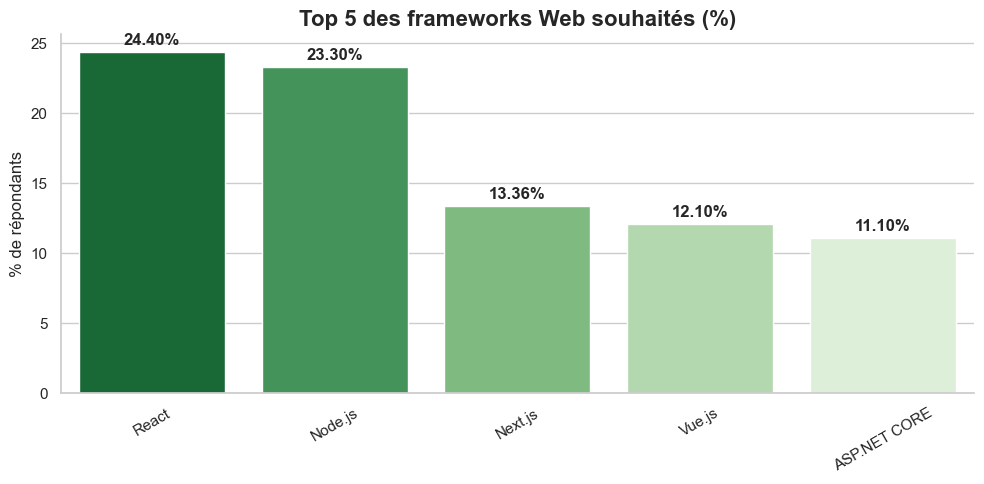

In [41]:
fw_sorted = fw_want_pct.sort_values(ascending=False)
colors = sns.color_palette("Greens_r", len(fw_sorted))

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=fw_sorted.index,
    y=fw_sorted.values,
    palette=colors
)

for i, v in enumerate(fw_sorted.values):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center", fontweight="bold")

plt.title("Top 5 des frameworks Web souhaités (%)", fontsize=16, fontweight="bold")
plt.xlabel("")
plt.ylabel("% de répondants")
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Technologies/Frameworks/09_webframe_wanted_top5.png", dpi=300, bbox_inches='tight')

plt.show()


#### Interprétation
Node.js et React dominent clairement l’usage actuel, reflet du poids massif de l’écosystème JavaScript. jQuery reste surtout lié au legacy, tandis que Next.js progresse doucement.
Côté préférences, React devient le framework le plus désiré, juste devant Node.js, preuve de sa centralité dans le développement moderne. Next.js et Vue.js gagnent en attractivité.
En bref : React et Node.js mènent, Next.js monte, jQuery décline.

## 7. Technologies Embedded (Embedded)

### 7.1. Technologies Embedded utilisées (EmbeddedHaveWorkedWith)

In [42]:
emb_have = df[["ResponseId", "EmbeddedHaveWorkedWith"]].dropna(
    subset=["EmbeddedHaveWorkedWith"]
).copy()

emb_have["EmbeddedHaveWorkedWith"] = emb_have["EmbeddedHaveWorkedWith"].str.split(";")
emb_have = emb_have.explode("EmbeddedHaveWorkedWith")
emb_have["EmbeddedHaveWorkedWith"] = emb_have["EmbeddedHaveWorkedWith"].str.strip()

emb_have_pct = (
    emb_have["EmbeddedHaveWorkedWith"]
    .value_counts()
    .head(5) * 100 / nb_repondants
).round(2)

emb_have_pct



EmbeddedHaveWorkedWith
Rasberry Pi     16.99
Arduino         13.00
GNU GCC         12.77
CMake           12.49
LLVM's Clang     7.53
Name: count, dtype: float64

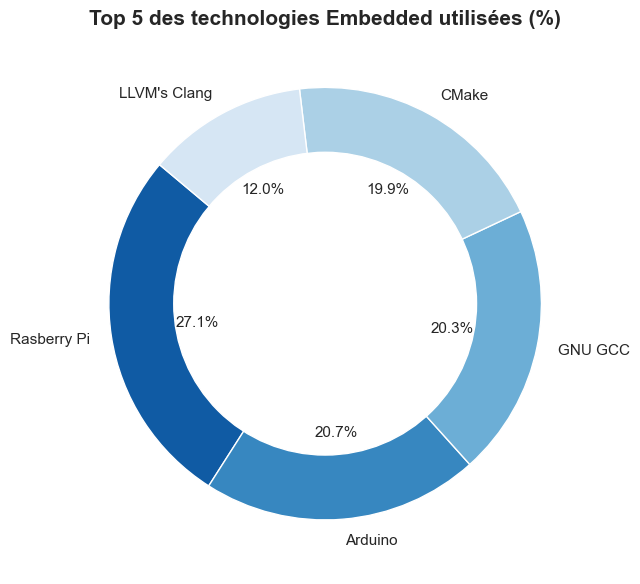

In [43]:
values = emb_have_pct.values
labels = emb_have_pct.index

colors = sns.color_palette("Blues_r", len(values))

plt.figure(figsize=(8, 6))

# Donut
wedges, texts, autotexts = plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    textprops={"fontsize": 11}
)

# Cercle blanc central
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Top 5 des technologies Embedded utilisées (%)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../Reports/Figures/Technologies/Embedded/09_embedded_used_top5.png", dpi=300, bbox_inches='tight')
plt.show()


### 7.2. Technologies Embedded souhaitées (EmbeddedWantToWorkWith)

In [44]:
emb_want = df[["ResponseId", "EmbeddedWantToWorkWith"]].dropna(
    subset=["EmbeddedWantToWorkWith"]
).copy()

emb_want["EmbeddedWantToWorkWith"] = emb_want["EmbeddedWantToWorkWith"].str.split(";")
emb_want = emb_want.explode("EmbeddedWantToWorkWith")
emb_want["EmbeddedWantToWorkWith"] = emb_want["EmbeddedWantToWorkWith"].str.strip()

emb_want_pct = (
    emb_want["EmbeddedWantToWorkWith"]
    .value_counts()
    .head(5) * 100 / nb_repondants
).round(2)

emb_want_pct



EmbeddedWantToWorkWith
Rasberry Pi    15.37
Arduino        10.12
GNU GCC         9.21
CMake           7.40
Cargo           7.19
Name: count, dtype: float64

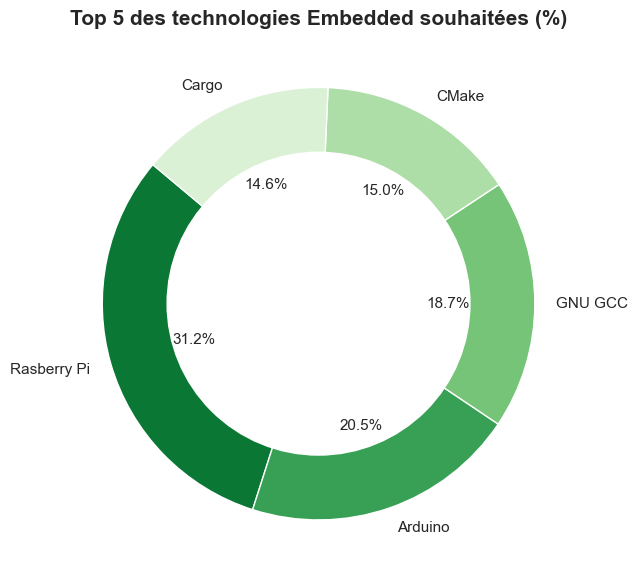

In [45]:


values = emb_want_pct.values
labels = emb_want_pct.index

colors = sns.color_palette("Greens_r", len(values))

plt.figure(figsize=(8, 6))

# Donut
wedges, texts, autotexts = plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    textprops={"fontsize": 11}
)

# Cercle blanc central
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Top 5 des technologies Embedded souhaitées (%)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../Reports/Figures/Technologies/Embedded/09_embedded_wanted_top5.png", dpi=300, bbox_inches='tight')

plt.show()


#### interpretation
Raspberry Pi domine largement, aussi bien dans l’usage actuel que dans les préférences futures, preuve qu’il reste la plateforme incontournable pour l’embarqué accessible, éducatif et prototypage rapide. Arduino suit la même logique, toujours très présent grâce à sa simplicité.
Côté outils, GNU GCC et CMake restent des standards solides du développement bas-niveau.
La différence notable est l’apparition de Cargo dans les technologies souhaitées, signe d’un intérêt croissant pour Rust dans l’embarqué moderne.

En bref : Raspberry Pi et Arduino restent la base, GCC/CMake les outils clés, et Rust commence à se frayer un chemin.

## 8. Systèmes d’exploitation professionnels (OpSysProfessional use)

In [46]:
# Extraction simple
os_use = df[["ResponseId", "OpSysProfessional use"]].dropna(
    subset=["OpSysProfessional use"]
).copy()

# Split des réponses multivaluées
os_use["OpSysProfessional use"] = os_use["OpSysProfessional use"].str.split(";")
os_use = os_use.explode("OpSysProfessional use")
os_use["OpSysProfessional use"] = os_use["OpSysProfessional use"].str.strip()
os_pct = (
    os_use["OpSysProfessional use"]
    .value_counts()
    .head(5) * 100 / nb_repondants
).round(2)

os_pct


OpSysProfessional use
Windows                              44.56
MacOS                                30.01
Ubuntu                               26.05
Windows Subsystem for Linux (WSL)    15.80
Debian                                8.53
Name: count, dtype: float64

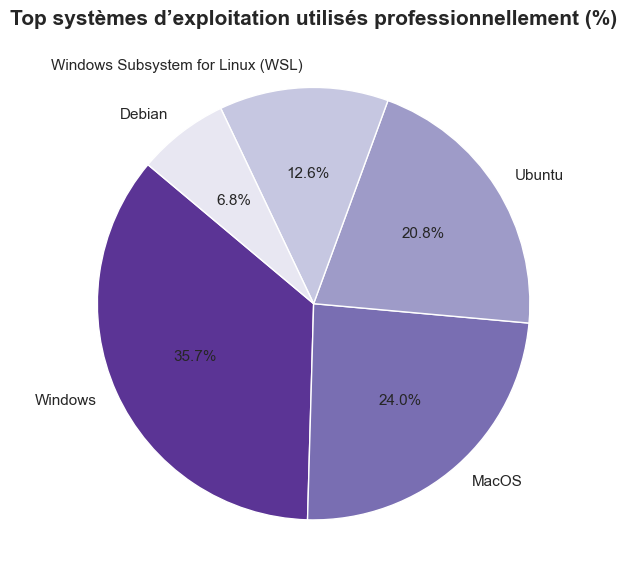

In [47]:
values = os_pct.values
labels = os_pct.index

plt.figure(figsize=(8, 6))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("Purples_r", len(values)),
    textprops={"fontsize": 11}
)

plt.title("Top systèmes d’exploitation utilisés professionnellement (%)",
          fontsize=15, fontweight="bold")

plt.tight_layout()
plt.savefig("../Reports/Figures/Technologies/OS/09_os_used_top5.png", dpi=300, bbox_inches='tight')
plt.show()


#### Interprétation 

Windows reste clairement la plateforme professionnelle dominante. macOS suit avec une forte présence, portée par son adoption dans le développement web et mobile. Ubuntu arrive en troisième position, confirmant le rôle central de Linux dans les environnements serveur et devops.
WSL occupe une place notable, preuve que beaucoup de développeurs Windows utilisent une couche Linux pour travailler. Debian ferme le classement, davantage présent chez les profils Linux plus avancés.

## 9. Outils collaboratifs utilisés (NEWCollabToolsHaveWorkedWith)

In [48]:
# Extraction simple
col_use = df[["ResponseId", "NEWCollabToolsHaveWorkedWith"]].dropna(
    subset=["NEWCollabToolsHaveWorkedWith"]
).copy()

# Split des réponses multivaluées
col_use["NEWCollabToolsHaveWorkedWith"] = col_use["NEWCollabToolsHaveWorkedWith"].str.split(";")
col_use = col_use.explode("NEWCollabToolsHaveWorkedWith")
col_use["NEWCollabToolsHaveWorkedWith"] = col_use["NEWCollabToolsHaveWorkedWith"].str.strip()
col_pct = (
    col_use["NEWCollabToolsHaveWorkedWith"]
    .value_counts()
    .head(5) * 100 / nb_repondants
).round(2)

col_pct


NEWCollabToolsHaveWorkedWith
Visual Studio Code    67.99
Visual Studio         27.12
IntelliJ IDEA         24.66
Notepad++             22.21
Vim                   20.02
Name: count, dtype: float64

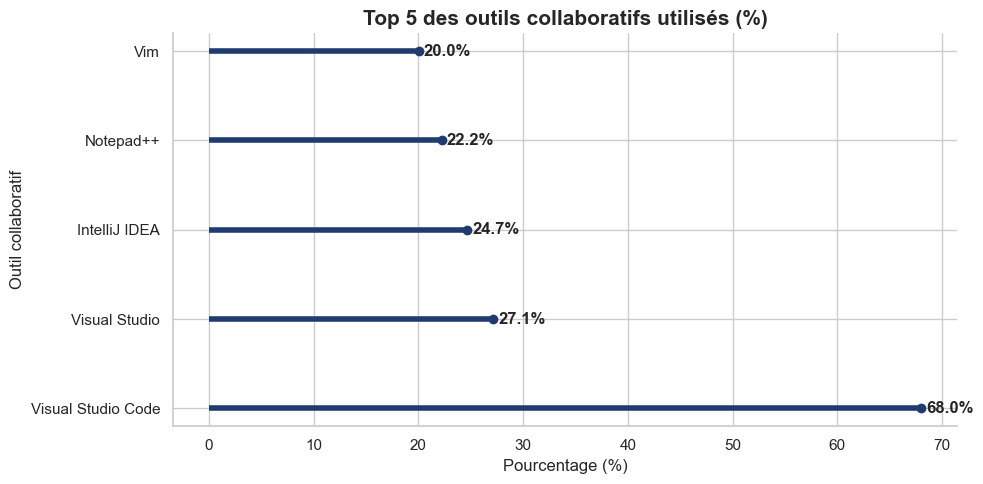

In [49]:
plt.figure(figsize=(10, 5))

# Barres horizontales
plt.hlines(
    y=col_pct.index,
    xmin=0,
    xmax=col_pct.values,
    color="#1f3b70",     # bleu foncé
    linewidth=4
)

# Points au bout des barres
plt.plot(
    col_pct.values,
    col_pct.index,
    "o",
    color="#1f3b70"
)

# Labels %
for i, v in enumerate(col_pct.values):
    plt.text(v + 0.5, col_pct.index[i], f"{v:.1f}%", va="center", fontweight="bold")

plt.title("Top 5 des outils collaboratifs utilisés (%)",
          fontsize=15, fontweight="bold")

plt.xlabel("Pourcentage (%)")
plt.ylabel("Outil collaboratif")

sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Technologies/Collab/09_collabtools_used_top5.png", dpi=300, bbox_inches='tight')

plt.show()


#### Interprétation

Visual Studio Code écrase tout le reste : c’est de loin l’outil le plus utilisé, grâce à sa légèreté, son écosystème d’extensions et sa polyvalence. Visual Studio et IntelliJ IDEA occupent une place solide dans les environnements plus structurés (C#, Java). Notepad++ et Vim restent utilisés par habitude ou pour des tâches rapides.

## 10. Usages de l’IA par les développeurs (AIToolCurrently Using)

In [50]:
# Extraction simple
ai_use = df[["ResponseId", "AIToolCurrently Using"]].dropna(
    subset=["AIToolCurrently Using"]
).copy()

# Split des réponses multivaluées
ai_use["AIToolCurrently Using"] = ai_use["AIToolCurrently Using"].str.split(";")
ai_use = ai_use.explode("AIToolCurrently Using")
ai_use["AIToolCurrently Using"] = ai_use["AIToolCurrently Using"].str.strip()

# TOP 5 en pourcentage (principaux usages)
ai_pct = (
    ai_use["AIToolCurrently Using"]
    .value_counts()
    .head(5) * 100 / nb_repondants
).round(2)

ai_pct



AIToolCurrently Using
Writing code                            46.54
Search for answers                      38.29
Debugging and getting help              32.06
Documenting code                        22.84
Generating content or synthetic data    19.79
Name: count, dtype: float64

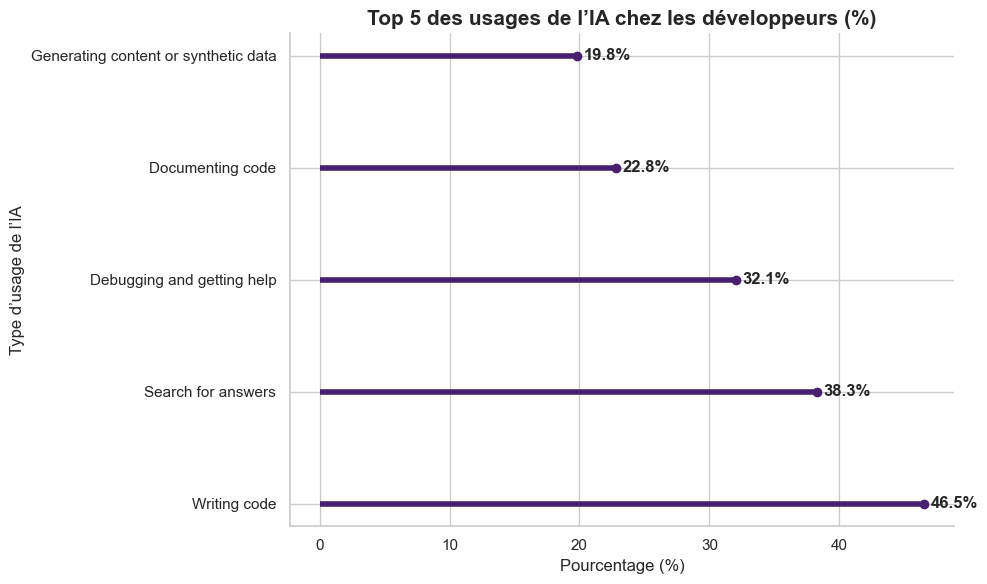

In [27]:
plt.figure(figsize=(10, 6))

# Barres horizontales
plt.hlines(
    y=ai_pct.index,
    xmin=0,
    xmax=ai_pct.values,
    color="#4b1f70",     # violet foncé
    linewidth=4
)

# Points au bout des barres
plt.plot(
    ai_pct.values,
    ai_pct.index,
    "o",
    color="#4b1f70"
)

# Labels %
for i, v in enumerate(ai_pct.values):
    plt.text(v + 0.5, ai_pct.index[i], f"{v:.1f}%", va="center", fontweight="bold")

plt.title("Top 5 des usages de l’IA chez les développeurs (%)",
          fontsize=15, fontweight="bold")

plt.xlabel("Pourcentage (%)")
plt.ylabel("Type d’usage de l’IA")

sns.despine()
plt.tight_layout()
plt.savefig("../Reports/Figures/Technologies/AI/09_ai_use_cases_top5.png", dpi=300, bbox_inches='tight')

plt.show()




#### Interprétation

Les développeurs utilisent principalement l’IA pour **écrire du code**, suivie par la **recherche de réponses** et l’**aide au débogage**.  
Les usages plus périphériques comme la **documentation du code** ou la **génération de contenu / données synthétiques** restent moins fréquents.

En clair : l’IA sert d’abord à accélérer le développement et la compréhension du code, plus qu’à automatiser l’ensemble du travail.


## **Résumé**

Cette analyse met en évidence les grandes tendances technologiques observées dans le Survey 2024 :

- **Bases de données**  
  Les usages actuels sont dominés par PostgreSQL, MySQL et SQLite.  
  Dans les préférences, PostgreSQL s’impose encore davantage tandis que MongoDB et Redis gagnent en attractivité grâce à leur flexibilité et leur modèle open-source.

- **Plateformes**  
  AWS domine clairement, aussi bien dans l’usage que dans les intentions futures.  
  Azure et Google Cloud suivent, alors que Cloudflare et Firebase occupent des usages plus ciblés liés au web et au mobile.

- **Frameworks Web**  
  Node.js et React constituent le cœur de l’écosystème JavaScript moderne.  
  Next.js monte en puissance dans les souhaits, tandis que jQuery recule et reste cantonné aux projets legacy.

- **Technologies Embedded**  
  Raspberry Pi et Arduino sont les piliers du prototypage et de l’apprentissage.  
  GCC et CMake restent les outils standards du développement bas-niveau.  
  L’apparition de Cargo dans les préférences traduit l’intérêt croissant pour Rust dans l’embarqué.

- **Systèmes d’exploitation**  
  Windows domine l’usage professionnel.  
  macOS conserve une forte présence, et Ubuntu/WSL confirment l’importance de Linux dans les environnements devops.

- **Outils collaboratifs**  
  Visual Studio Code s’impose largement grâce à sa simplicité et son écosystème d’extensions.  
  Visual Studio, IntelliJ IDEA, Notepad++ et Vim restent bien implantés selon les contextes.

- **Outils d’IA**  
  L’IA est principalement utilisée pour écrire du code, chercher des réponses et déboguer.  
  Les usages secondaires — documentation, génération de contenu synthétique — restent moins fréquents.


